# SSH Brute-Force Detection — v4: one multiclass model

**What changed from v3.** v3 shipped a *binary* Random Forest (Attack / Legit). v4 ships **one multiclass Random Forest** that gives both answers in a single model: *is it an attack* and *which behaviour is it*. There are 11 classes, 3 legit behaviours and 8 attack types mapped to MITRE ATT&CK Brute Force (T1110).

Same data (`ssh_features_v3*.csv`), same 16 features, same train/test split as v3. The feature-selection evidence lives in `ssh_bruteforce_pipeline_v3_executed.ipynb` and is not repeated here.

The training, export and decision rule are implemented in `train_multiclass_model.py`, which this notebook imports, so the notebook and the deployed model cannot drift apart.

| | v3 binary (old) | **v4 multiclass (deployed)** |
|---|---|---|
| Output | Attack / Legit | Attack / Legit **+** 1 of 11 behaviours |
| Test F1 (Attack/Legit) | 0.982 | **0.984** |
| OOD F1 (Attack/Legit) | 0.984 | **0.985** |
| False positives test / OOD | 3 / 1 | **0 / 0** |
| Class macro-F1 test / OOD | – | **0.991 / 0.992** |

(numbers computed below)

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.metrics import f1_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import train_multiclass_model as T
pd.set_option("display.width", 200); pd.set_option("display.max_columns", None)
F = T.FEATURE_COLUMNS

## 1. Why 11 classes and not all 14 generator patterns

The generator (`generate_v3_dataset.py`) has 14 behaviour patterns. Training one class per pattern shows that some of them **cannot be told apart from the 16 features**, by the generator's own design:

- `legit_multi_ip_roaming` writes one successful login per IP. The generator's docstring calls this *"indistinguishable from legit_success at the session level"*. Telling them apart needs a per-USER cross-IP view, which no feature provides.
- `ambiguous_legit` is a typo user with more failed attempts. `ambiguous_attack` is an attack generated to look exactly like `legit_typo`.

The cell below trains on the raw 14 patterns and shows the result: low recall for these patterns, and real typo users predicted as attacks.

In [2]:
df = pd.read_csv("ssh_features_v3.csv"); ood = pd.read_csv("ssh_features_v3_ood.csv")
tr14, te14 = train_test_split(df, test_size=0.25, random_state=42, stratify=df["Attack_Type"])
m14 = RandomForestClassifier(**T.RF_PARAMS).fit(tr14[F], tr14["Attack_Type"])
p14 = m14.predict(ood[F])
labs = sorted(ood["Attack_Type"].unique())
pd.DataFrame({"OOD recall (14 raw patterns)": recall_score(ood["Attack_Type"], p14, labels=labs, average=None).round(3)},
             index=labs).sort_values("OOD recall (14 raw patterns)")

,OOD recall (14 raw patterns)
ambiguous_attack,0.000
legit_multi_ip_roaming,0.121
ambiguous_legit,0.800
focused_bruteforce,0.850
password_spray,0.962
legit_success,0.975
legit_typo,0.993
coordinated_botnet_spike,1.000
large_dictionary_scanner,1.000
credential_stuffing,1.000


**Decision:** merge what the features cannot separate, and leave out what has no learnable signature:

| Model class | Generator pattern(s) |
|---|---|
| `legit_login` | legit_success + legit_multi_ip_roaming |
| `legit_typo` | legit_typo + ambiguous_legit |
| `shared_ip_legit` | shared_ip_legit |
| 8 attack classes | one pattern each |
| *(not trained)* | ambiguous_attack: still in test/OOD and counted as an attack in every binary metric |

In [3]:
train_df, test_df, ood_df = T.load_splits()
pd.DataFrame({"train": train_df["Class"].value_counts(), "test": test_df["Class"].value_counts(),
              "ood": ood_df["Class"].value_counts()}).assign(group=lambda d: ["attack" if c in T.ATTACK_CLASSES else "legit" for c in d.index])

,train,test,ood,group
Class,,,,
low_and_slow,808,270,929,attack
legit_login,586,196,667,legit
legit_typo,412,138,468,legit
burst_bruteforce,330,110,374,attack
persistent_multiday_attacker,262,87,334,attack
coordinated_botnet_spike,216,72,178,attack
password_spray,82,27,106,attack
shared_ip_legit,80,27,81,legit
focused_bruteforce,52,18,60,attack


## 2. Decision rule

One model returns 11 class probabilities. The rule is the same in the training script, `backend/pipeline.py` and `web/js/model.js`:

- `risk` = sum of the 8 attack-class probabilities (the Risk score in the UI)
- `risk >= threshold` → **Attack**, and the label is the most likely *attack* class; otherwise **Legit**, and the label is the most likely *legit* class. So the label never contradicts Attack/Legit.
- The label's confidence is P(label) / P(its group). Below 0.6 the UI shows "not sure (closest: …)".

## 3. Model selection — 5-fold CV on the TRAINING set only

Test and OOD are not used here. Each candidate is scored on out-of-fold predictions (threshold 0.5) for Attack/Legit F1, class macro-F1, and focused_bruteforce recall (the hardest attack class).

In [4]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)
X, y = train_df[F], train_df["Class"]
foc = (train_df["Attack_Type"] == "focused_bruteforce").values
def cv_row(name, est, needs_codes=False):
    yy = y.astype("category").cat.codes if needs_codes else y
    oof = cross_val_predict(est, X, yy, cv=cv, method="predict_proba")
    classes = sorted(y.unique())
    risk, is_attack, label, _ = T.decide(oof, classes, 0.5)
    return {"model": name, "binary F1": f1_score(train_df["Label"], is_attack), "class macro-F1": f1_score(y, label, average="macro"),
            "focused recall": is_attack[foc].mean()}
base = {k: v for k, v in T.RF_PARAMS.items() if k not in ("max_features", "max_depth", "class_weight")}
rows = [
    cv_row("LogReg (scaled)", Pipeline([("s", StandardScaler()), ("c", LogisticRegression(max_iter=5000))])),
    cv_row("XGBoost 400 rounds", XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1, subsample=0.9,
                                               eval_metric="mlogloss", random_state=42, n_jobs=-1), needs_codes=True),
    cv_row("RF depth 8, sqrt, balanced", RandomForestClassifier(**base, max_depth=8, class_weight="balanced")),
    cv_row("RF depth 8, sqrt", RandomForestClassifier(**base, max_depth=8)),
    cv_row("RF depth 12, sqrt", RandomForestClassifier(**base, max_depth=12)),
    cv_row("RF depth 8, max_features 0.5", RandomForestClassifier(**base, max_depth=8, max_features=0.5)),
    cv_row("RF depth 8, max_features 0.7  <- deployed", RandomForestClassifier(**T.RF_PARAMS)),
]
pd.DataFrame(rows).set_index("model").round(4)

,binary F1,class macro-F1,focused recall
model,,,
LogReg (scaled),0.9964,0.9824,0.8846
XGBoost 400 rounds,0.9961,0.9836,0.9038
"RF depth 8, sqrt, balanced",0.9926,0.9773,0.9423
"RF depth 8, sqrt",0.9961,0.9860,0.8462
"RF depth 12, sqrt",0.9964,0.9871,0.8654
"RF depth 8, max_features 0.5",0.9972,0.9896,0.8462
"RF depth 8, max_features 0.7 <- deployed",0.9978,0.9912,0.8654


**Choice:** Random Forest, depth 8, `max_features=0.7`, no class weighting. It has the best CV class macro-F1 and binary F1 among the Random Forests, and it is level with XGBoost. A Random Forest is kept because it exports to JSON and runs in the browser with a ~50-line tree walker. Depth stays at 8 so `forest.json` stays under 1 MB. `class_weight="balanced"` is dropped because it blurs the three legit classes.

## 4. Threshold (from train CV) and the final model

In [5]:
threshold = T.pick_threshold(train_df)
model = RandomForestClassifier(**T.RF_PARAMS).fit(train_df[F], train_df["Class"])
deployed = joblib.load("ssh_bruteforce_multiclass.joblib")
print("threshold chosen on train CV:", threshold, "| deployed bundle threshold:", deployed["threshold"])
print("identical predictions to the deployed model on OOD:",
      np.allclose(model.predict_proba(ood_df[F]), deployed["model"].predict_proba(ood_df[F])))

threshold chosen on train CV: 0.57 | deployed bundle threshold: 0.57


identical predictions to the deployed model on OOD: True


## 5. Results — test and OOD

In [6]:
res = {s: T.evaluate(model, d, threshold) for s, d in [("test", test_df), ("ood", ood_df)]}
pd.DataFrame({s: {**{f"binary {k}": v for k, v in r["binary"].items() if k != "confusion_tn_fp_fn_tp"},
                  "TN, FP, FN, TP": r["binary"]["confusion_tn_fp_fn_tp"],
                  "class accuracy": r["classes"]["accuracy"], "class macro-F1": r["classes"]["macro_f1"]}
              for s, r in res.items()})

,test,ood
binary pr_auc,0.995629,0.994926
binary roc_auc,0.99329,0.991902
binary precision,1.0,1.0
binary recall,0.969256,0.969524
binary f1,0.984388,0.984526
binary accuracy,0.980592,0.9807
"TN, FP, FN, TP","[361, 0, 19, 599]","[1216, 0, 64, 2036]"
class accuracy,0.996885,0.996933
class macro-F1,0.990758,0.992412


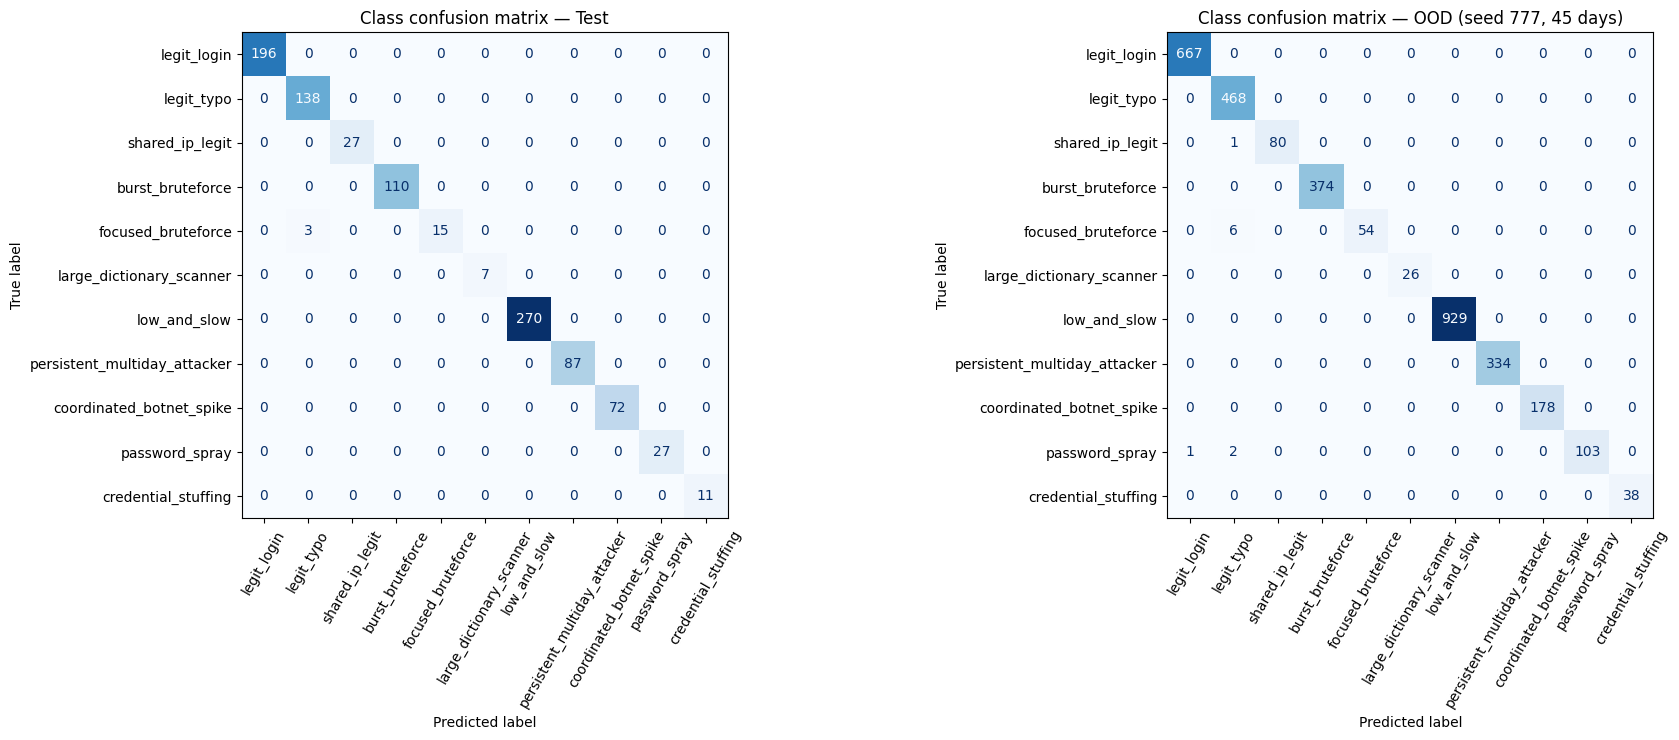

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(19, 7.5))
labels = T.LEGIT_CLASSES + T.ATTACK_CLASSES
for ax, (name, d) in zip(axes, [("Test", test_df), ("OOD (seed 777, 45 days)", ood_df)]):
    known = d["Class"].notna()
    _, _, lab, _ = T.decide(model.predict_proba(d.loc[known, F]), model.classes_, threshold)
    ConfusionMatrixDisplay(confusion_matrix(d.loc[known, "Class"], lab, labels=labels), display_labels=labels).plot(
        ax=ax, cmap="Blues", colorbar=False, xticks_rotation=60)
    ax.set_title(f"Class confusion matrix — {name}")
plt.tight_layout(); plt.show()

In [8]:
pd.DataFrame({s: {k: f"{v['group_correct']:.3f} / " + ("-" if v["class_correct"] is None else f"{v['class_correct']:.3f}")
                  for k, v in r["by_original_pattern"].items()} for s, r in res.items()}).rename_axis(
    "original pattern  (right group / right class)")

,test,ood
original pattern (right group / right class),,
ambiguous_attack,0.000 / -,0.000 / -
ambiguous_legit,1.000 / 1.000,1.000 / 1.000
burst_bruteforce,1.000 / 1.000,1.000 / 1.000
coordinated_botnet_spike,1.000 / 1.000,1.000 / 1.000
credential_stuffing,1.000 / 1.000,1.000 / 1.000
focused_bruteforce,0.833 / 0.833,0.900 / 0.900
large_dictionary_scanner,1.000 / 1.000,1.000 / 1.000
legit_multi_ip_roaming,1.000 / 1.000,1.000 / 1.000
legit_success,1.000 / 1.000,1.000 / 1.000


**Reading the table:** the only misses are
- `ambiguous_attack`: not trained, and labelled `legit_typo`. It was 0% in v3 too. This is a known blind spot of log features, not a v4 regression.
- `focused_bruteforce` with few failed attempts: below about 13 fails on a real-looking account it overlaps the typo user by design.
- A few small single-IP `password_spray` sessions.

## 6. Sanity checks

In [9]:
rng = np.random.default_rng(0)
known = test_df["Class"].notna()
shuf = RandomForestClassifier(**T.RF_PARAMS).fit(train_df[F], rng.permutation(train_df["Class"].values))
print("shuffled-label test class macro-F1:", round(f1_score(test_df.loc[known, "Class"], shuf.predict(test_df.loc[known, F]), average="macro"), 3),
      "(real model:", round(res["test"]["classes"]["macro_f1"], 3), ")")
print("ambiguous_attack in OOD:", res["ood"]["ambiguous_attack_not_trained"])

shuffled-label test class macro-F1: 0.045 (real model: 0.991 )
ambiguous_attack in OOD: {'n': 55, 'detected_as_attack': 0.0, 'labelled_as': {'legit_typo': 55}}


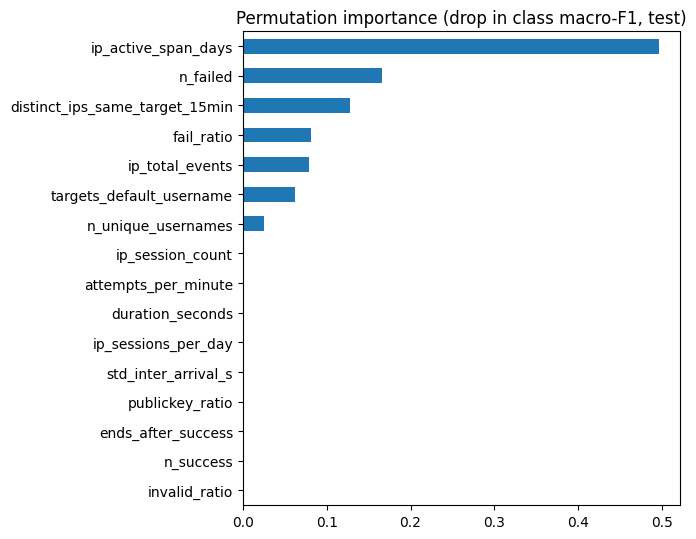

In [10]:
known_t = test_df["Class"].notna()
pi = permutation_importance(model, test_df.loc[known_t, F], test_df.loc[known_t, "Class"], scoring="f1_macro",
                            n_repeats=10, random_state=42, n_jobs=-1)
pd.Series(pi.importances_mean, index=F).sort_values().plot.barh(figsize=(7, 5.5))
plt.title("Permutation importance (drop in class macro-F1, test)"); plt.tight_layout(); plt.show()

## 7. End-to-end on a RAW log through the production code

The numbers above use pre-computed features. The cell below sends the **raw** OOD log (32,965 lines, never used in training) through `backend/pipeline.py`, the same code the web backend runs: CSV loading → session split → features → model → decision rule.

It also shows why the web default session gap was changed from 30 to 10 minutes, the gap the training sessions were built with.

In [11]:
sys.path.insert(0, "../backend"); import pipeline as P
raw = open("ssh_dataset_v3_ood.csv", "rb").read()   # the file also carries the answer columns; the pipeline ignores them
for gap in (10, 30):
    d = P.segment_sessions(P.load_log_dataframe(raw), gap)
    out = P.build_session_results(d, deployed)
    sid_truth = d.assign(Label=d["Label"].astype(int)).groupby("Session_ID").agg(
        Label=("Label", lambda s: int(s.mean() >= .5)), Attack_Type=("Attack_Type", lambda s: s.mode()[0]))
    r = pd.DataFrame(out).set_index("session_id").join(sid_truth)
    known = r["Attack_Type"].map(T.CLASS_MAP).notna()
    print(f"gap {gap:2d} min: {len(r)} sessions | Attack/Legit F1 {f1_score(r['Label'], r['is_attack']):.4f}"
          f" | class accuracy {(r.loc[known, 'label'] == r.loc[known, 'Attack_Type'].map(T.CLASS_MAP)).mean():.4f}")

gap 10 min: 3316 sessions | Attack/Legit F1 0.9845 | class accuracy 0.9969


gap 30 min: 2910 sessions | Attack/Legit F1 0.9812 | class accuracy 0.9965


The browser's JavaScript (`web/js/features.js` + `model.js`) was checked against this Python path separately. On the same raw OOD log, all 3,316 sessions have the same 16 feature values (differences ≤ 1 ms from timestamp precision). On 2,905 sessions from 23 files (demo logs, generated logs, converted auth.logs, malformed CSVs; viewer timezones Asia/Bangkok and America/New_York), labels and Attack/Legit decisions match 100%, with a maximum risk difference of 3e-8.

## 8. v4 vs the old v3 binary model (same test/OOD sets)

In [12]:
old = joblib.load("ssh_bruteforce_model_v3.joblib")["model"]
rows = []
for s, d in [("test", test_df), ("ood", ood_df)]:
    p_old = old.predict_proba(d[F])[:, 1] >= 0.55
    b = res[s]["binary"]
    rows += [{"set": s, "model": "v3 binary @0.55", "F1": f1_score(d["Label"], p_old),
              "FP": int((p_old & (d["Label"] == 0)).sum()), "FN": int((~p_old & (d["Label"] == 1)).sum())},
             {"set": s, "model": f"v4 multiclass @{threshold}", "F1": b["f1"],
              "FP": b["confusion_tn_fp_fn_tp"][1], "FN": b["confusion_tn_fp_fn_tp"][2]}]
pd.DataFrame(rows).set_index(["set", "model"]).round(4)

F1  FP  FN
set  model                              
test v3 binary @0.55      0.9820   3  19
     v4 multiclass @0.57  0.9844   0  19
ood  v3 binary @0.55      0.9840   1  65
     v4 multiclass @0.57  0.9845   0  64

## 9. Limitations — what these numbers do and do not show

- **Synthetic data.** Every class comes from a generator rule, so the classes are separable largely by construction. Near-perfect class scores show that the 16 features carry the information, not that real attackers fall into these 8 boxes this neatly. The model has not been validated on real traffic. The web app now accepts raw `auth.log` files, so that check can be run.
- **Blind spots:** `ambiguous_attack` (an attack shaped exactly like a mistyping user), and focused brute force with few attempts against a real-looking account. An attack with perfectly regular timing (e.g. exactly 1 s apart) also looks unlike anything in training.
- **IP-history classes** (persistent multi-day, botnet) depend on what is in the uploaded file. A short file has less history, so the IP-level features shrink.
- **Roaming users** are labelled `legit_login`. Recognising roaming would need a user-level feature (logins per user across IPs).